In [22]:
PROJECT_ID = "spring-2026-lifejacket"
REGION = "us-central1"
vertexai.init(project=PROJECT_ID, location=REGION)

In [1]:
from PIL import Image as PILImage
from PIL import ImageEnhance, ImageFilter
import random

In [2]:
DISTORTION_CONFIGS = {
    0: {
        "brightness": (1.0, 1.0),
        "contrast": (1.0, 1.0),
        "color": (1.0, 1.0),
        "sharpness": (1.0, 1.0),
        "rotate": False
    },

    1: {
        "brightness": (0.80, 1.20),
        "contrast": (0.85, 1.15),
        "color": (0.75, 1.25),
        "sharpness": (0.70, 1.30),
        "rotate": False
    },

    2: {
        "brightness": (0.60, 0.79),
        "contrast": (0.65, 0.84),
        "color": (0.50, 0.74),
        "sharpness": (0.20, 0.50),
        "rotate": False
    },

    3: {
        "brightness": (0.40, 0.59),
        "contrast": (0.35, 0.64),
        "color": (0.15, 0.49),
        "sharpness": (0.01, 0.15),
        "rotate": True
    },

    4: {
        "brightness": (0.20, 0.39),
        "contrast": (0.20, 0.34),
        "color": (0.01, 0.14),
        "sharpness": (0.0, 0.0),
        "rotate": True
    },

    5: {
        "brightness": (0.45, 0.55),
        "contrast": (0.05, 0.12),
        "color": (0.0, 0.0),
        "sharpness": (0.0, 0.0),
        "rotate": True
    }
}

In [3]:
def apply_distortion(image_path, distortion_level, output_folder="distorted_test_images"):
    os.makedirs(output_folder, exist_ok=True)

    config = DISTORTION_CONFIGS[distortion_level]

    img = PILImage.open(image_path).convert("RGB")

    # brightness
    brightness_factor = random.uniform(*config["brightness"])
    img = ImageEnhance.Brightness(img).enhance(brightness_factor)

    # contrast
    contrast_factor = random.uniform(*config["contrast"])
    img = ImageEnhance.Contrast(img).enhance(contrast_factor)

    # color
    color_factor = random.uniform(*config["color"])
    img = ImageEnhance.Color(img).enhance(color_factor)

    # sharpness
    sharpness_factor = random.uniform(*config["sharpness"])
    img = ImageEnhance.Sharpness(img).enhance(sharpness_factor)

    # additional blur for severe distortion
    if distortion_level >= 2:
        blur_radius = distortion_level * 0.8
        img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    # rotate if needed
    if config["rotate"]:
        angle = random.choice([90, 180, 270])
        img = img.rotate(angle, expand=True)

    base_name = os.path.splitext(os.path.basename(image_path))[0]
    output_path = os.path.join(
        output_folder,
        f"{base_name}_distortion_level_{distortion_level}.jpg"
    )

    img.save(output_path, quality=90)

    return output_path

In [4]:
import vertexai
import pandas as pd
import os
import mimetypes
import json
import re

from IPython.display import Image, display
from vertexai.generative_models import (
    GenerativeModel,
    Part,
    ChatSession,
    HarmCategory,
    HarmBlockThreshold
)

/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.aiplatform_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.aiplatform_v1beta1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1beta1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_supp

In [5]:
generation_config = {
    "temperature": 0.2,
    "top_p": 0.8,
    "top_k": 40,
    "max_output_tokens": 8192,
}

cv_model = GenerativeModel(
    "gemini-2.5-flash",
    generation_config=generation_config
)

llm_model = GenerativeModel(
    "gemini-2.5-flash",
    generation_config=generation_config
)

/opt/conda/lib/python3.10/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Number of images found: 399
First 10 images: ['330933465.jpg', '341153933.jpg', '346684207.jpg', '335518879.jpg', '320945320.jpg', '262976150.jpg', '328221101.jpg', '286423259.jpg', '347620194.jpg', '315539579.jpg']
Selected image: 261125066.jpg
Image path: Gemini Confidence Testing/hurt_animal_dataset_images/261125066.jpg


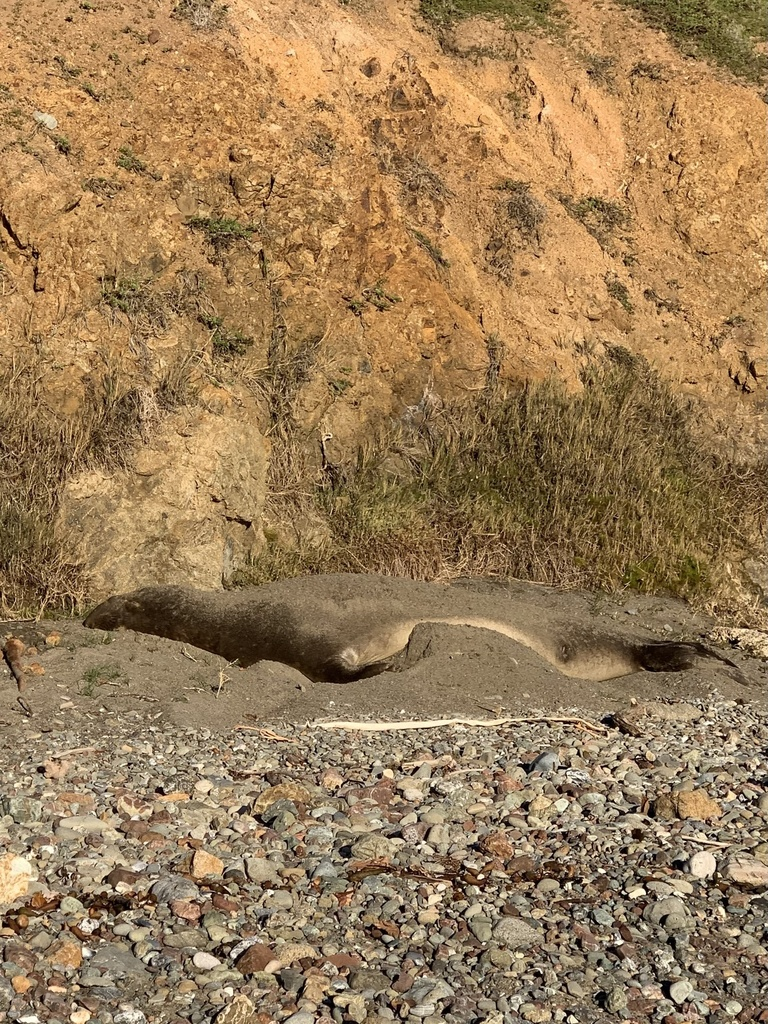

In [6]:
# real CV input from injury image folder

import os
from IPython.display import Image, display

IMAGE_FOLDER = "Gemini Confidence Testing/hurt_animal_dataset_images"

image_files = [
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

print("Number of images found:", len(image_files))
print("First 10 images:", image_files[:10])

IMAGE_INDEX = 15

image_filename = image_files[IMAGE_INDEX]
image_path = os.path.join(IMAGE_FOLDER, image_filename)

print("Selected image:", image_filename)
print("Image path:", image_path)

display(Image(filename=image_path, width=350))

Original image path: Gemini Confidence Testing/hurt_animal_dataset_images/261125066.jpg
Distorted image path: distorted_test_images/261125066_distortion_level_2.jpg

Original image:


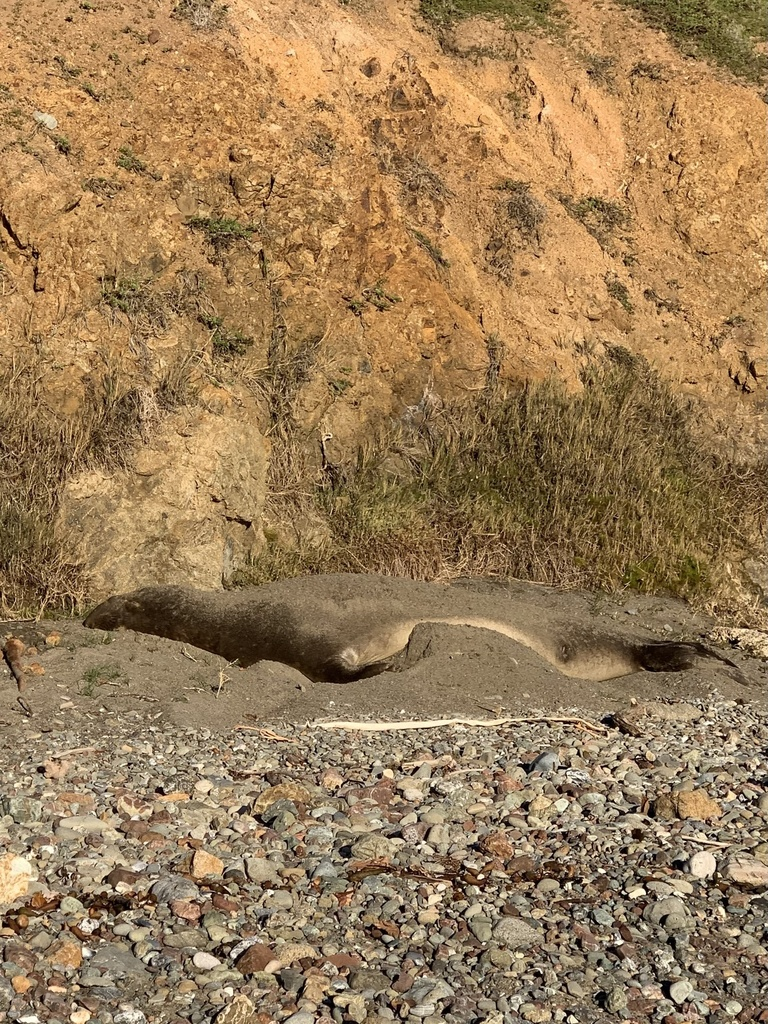


Distorted image:


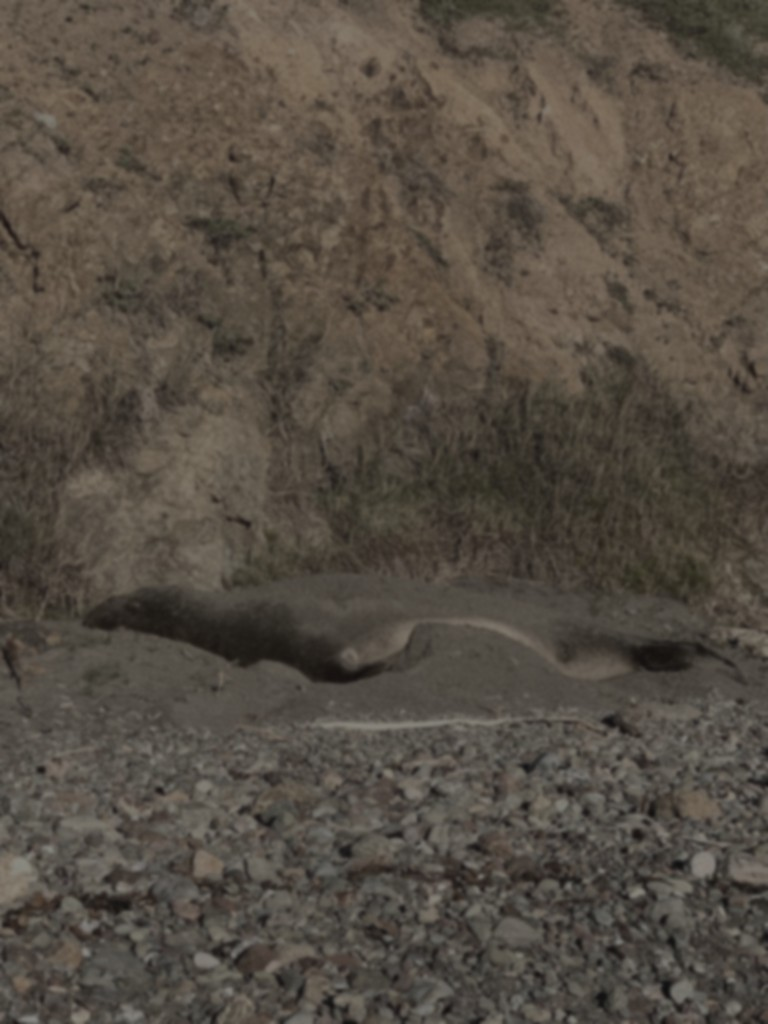

In [7]:
DISTORTION_LEVEL = 2

distorted_image_path = apply_distortion(
    image_path=image_path,
    distortion_level=DISTORTION_LEVEL,
    output_folder="distorted_test_images"
)

print("Original image path:", image_path)
print("Distorted image path:", distorted_image_path)

print("\nOriginal image:")
display(Image(filename=image_path, width=300))

print("\nDistorted image:")
display(Image(filename=distorted_image_path, width=300))

CV will use this image:
distorted_test_images/261125066_distortion_level_2.jpg


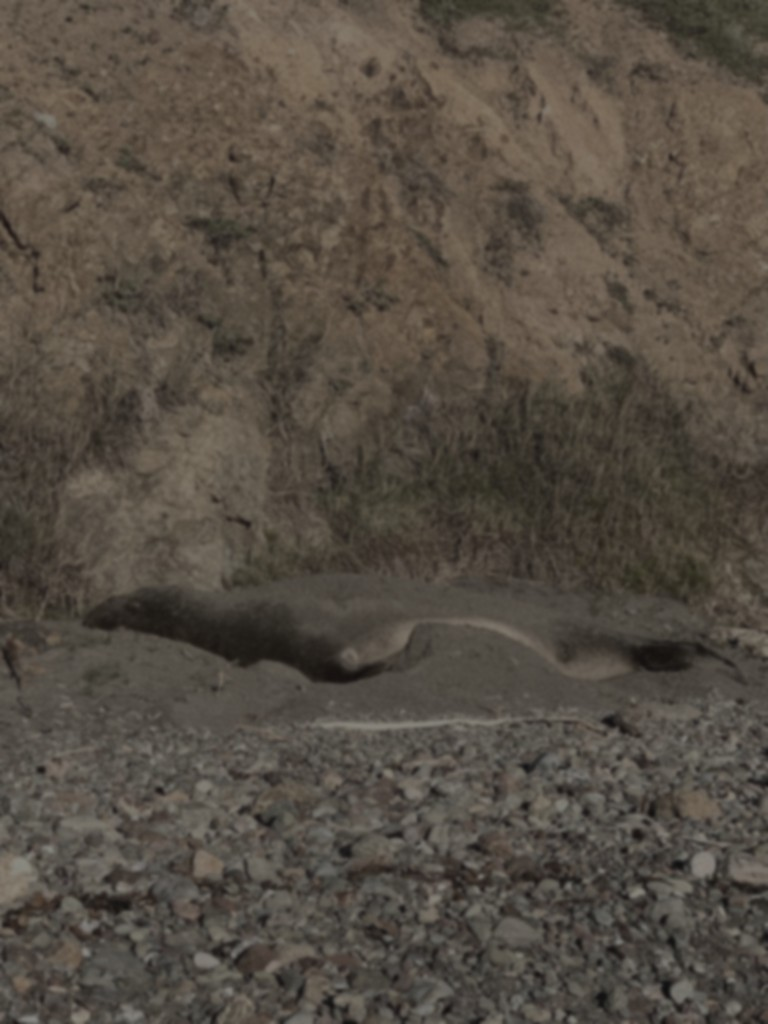

In [8]:
cv_image_path = distorted_image_path

print("CV will use this image:")
print(cv_image_path)

display(Image(filename=cv_image_path, width=350))

In [9]:
#mock location output
location_output = {
    "location_available": False,
    "location_source": "mock_location_for_testing",
    "latitude": None,
    "longitude": None,
    "place_name": "Unknown test location",
    "image_filename": image_filename,
    "image_date": "",
    "image_time": ""
}

print("Mock location output:")
print(json.dumps(location_output, indent=2))

Mock location output:
{
  "location_available": false,
  "location_source": "mock_location_for_testing",
  "latitude": null,
  "longitude": null,
  "place_name": "Unknown test location",
  "image_filename": "261125066.jpg",
  "image_date": "",
  "image_time": ""
}


In [10]:
def extract_json_from_response(text):
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```json", "", text)
        text = re.sub(r"^```", "", text)
        text = re.sub(r"```$", "", text)
        text = text.strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1 or end <= start:
        print("Raw response:")
        print(text)
        raise ValueError("No complete JSON object found in Gemini response.")

    json_text = text[start:end + 1]

    try:
        return json.loads(json_text)
    except json.JSONDecodeError as e:
        print("JSON parsing failed:", e)
        print("Extracted JSON text:")
        print(json_text)
        raise

## CV prompt +CV module

In [11]:
def build_cv_prompt(location_output):
    metadata_context = json.dumps(location_output, indent=2)

    return f"""
You are an expert wildlife species identification model executing a CDRL calibration process for a wildlife rescue dispatch system.

Observation metadata:
{metadata_context}

Task:
- Analyze the provided animal image.
- Identify the top 2 likely species or animal groups based on the image and available metadata.
- Estimate calibrated probabilities as integers from 0 to 100.
- Detect whether the image is clear enough for species and injury assessment.
- Detect whether there may be a visible wound.
- Detect whether visible blood appears.
- Provide a Maximum Confidence Query: one safe, non-invasive question an observer can answer from a distance using visual cues only.

Rules:
- A high probability requires definitive, unambiguous visual traits.
- Be honest and avoid overconfidence.
- If critical diagnostic features are missing, scale down probability.
- If the image is dark, blurry, blocked, or the animal is only partially visible, set image_clear to false or lower probabilities.
- Do not invent injury details that are not visible.
- If wound or blood cannot be determined, use false.
- The Maximum Confidence Query must be safe and answerable from a distance.
- Do not ask the observer to approach, touch, feed, move, measure, or disturb the animal.
- Return valid JSON only.
- Do not include markdown.
- Keep all string values short.

Return JSON exactly in this schema:
{{
  "cv_species_top2": [
    {{
      "common_name": "",
      "genus": "",
      "species": "",
      "probability": 0
    }},
    {{
      "common_name": "",
      "genus": "",
      "species": "",
      "probability": 0
    }}
  ],
  "cv_observed_features": {{
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "",
    "gaps_and_limits": "",
    "maximum_confidence_query": ""
  }}
}}
"""


def generate_cv_output_from_image(model, image_path, location_output):
    mime_type, _ = mimetypes.guess_type(image_path)
    if mime_type is None:
        mime_type = "image/jpeg"

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    image_part = Part.from_data(
        data=image_bytes,
        mime_type=mime_type
    )

    prompt = build_cv_prompt(location_output)

    response = model.generate_content([prompt, image_part])
    cv_output = extract_json_from_response(response.text)

    return cv_output

cv_output = generate_cv_output_from_image(
    model=cv_model,
    image_path=image_path,
    location_output=location_output
)

print("CV output:")
print(json.dumps(cv_output, indent=2))

In [12]:
distorted_cv_output = generate_cv_output_from_image(
    model=cv_model,
    image_path=cv_image_path,
    location_output=location_output
)

print("Distorted CV output:")
print(json.dumps(distorted_cv_output, indent=2))

Distorted CV output:
{
  "cv_species_top2": [
    {
      "common_name": "Seal",
      "genus": "Phocidae",
      "species": "Family",
      "probability": 85
    },
    {
      "common_name": "Sea Lion or Fur Seal",
      "genus": "Otariidae",
      "species": "Family",
      "probability": 15
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": false,
    "image_clarity_reason": "Image is dark, blurry, and distant, limiting detailed assessment.",
    "gaps_and_limits": "Specific species identification within the seal family is not possible. Detailed injury assessment is limited by image quality.",
    "maximum_confidence_query": "Can you see if the animal has small, visible ear flaps?"
  }
}


## Pre Fix question

In [13]:
fixed_question_options = {
    "reported_size": {
        "question": "What is the animal's approximate body length?",
        "options": {
            "A": "very_small_under_1_ft",
            "B": "small_1_to_3_ft",
            "C": "medium_3_to_6_ft",
            "D": "large_6_to_10_ft",
            "E": "very_large_over_10_ft",
            "F": "not_sure"
        }
    },
    "reported_body_covering": {
        "question": "What does the animal's body covering look like?",
        "options": {
            "A": "fur_or_hair",
            "B": "feathers",
            "C": "scales_or_shell",
            "D": "smooth_skin",
            "E": "not_sure"
        }
    },
    "reported_mobility": {
        "question": "Is the animal moving?",
        "options": {
            "A": "moving_normally",
            "B": "moving_slowly_or_weakly",
            "C": "not_moving_but_appears_alive",
            "D": "not_moving_may_be_dead",
            "E": "not_sure"
        }
    },
    "reported_visible_wound": {
        "question": "Do you see any visible wound?",
        "options": {
            "A": True,
            "B": False,
            "C": "not_sure"
        }
    },
    "reported_extra_condition": {
        "question": "Please briefly describe anything else you notice about the animal's condition, such as bleeding, entanglement, breathing, posture, nearby people, or unusual behavior.",
        "free_response": True
    }
}

In [14]:
def ask_fixed_questions(fixed_question_options):
    user_fixed_answers = {}

    for key, item in fixed_question_options.items():
        print("\n" + item["question"])

        if item.get("free_response", False):
            answer = input("Your answer: ").strip()
            user_fixed_answers[key] = answer if answer else "not_provided"
            continue

        options = item["options"]

        for letter, value in options.items():
            print(f"{letter}: {value}")

        while True:
            choice = input("Choose one option: ").strip().upper()

            if choice in options:
                user_fixed_answers[key] = options[choice]
                break

            print("Invalid option. Please choose one of:", list(options.keys()))

    return user_fixed_answers


user_fixed_answers = ask_fixed_questions(fixed_question_options)

print("\nUser fixed answers:")
print(json.dumps(user_fixed_answers, indent=2))


What is the animal's approximate body length?
A: very_small_under_1_ft
B: small_1_to_3_ft
C: medium_3_to_6_ft
D: large_6_to_10_ft
E: very_large_over_10_ft
F: not_sure


Choose one option:  F



What does the animal's body covering look like?
A: fur_or_hair
B: feathers
C: scales_or_shell
D: smooth_skin
E: not_sure


Choose one option:  A



Is the animal moving?
A: moving_normally
B: moving_slowly_or_weakly
C: not_moving_but_appears_alive
D: not_moving_may_be_dead
E: not_sure


...


Do you see any visible wound?
A: True
B: False
C: not_sure


Choose one option:  A



Please briefly describe anything else you notice about the animal's condition, such as bleeding, entanglement, breathing, posture, nearby people, or unusual behavior.


Your answer:  normal



User fixed answers:
{
  "reported_size": "not_sure",
  "reported_body_covering": "fur_or_hair",
  "reported_mobility": "moving_normally",
  "reported_visible_wound": true,
  "reported_extra_condition": "normal"
}


## Incident Package

In [15]:
incident_package = {
    "cv_output": distorted_cv_output,
    "location_output": location_output,
    "user_fixed_answers": user_fixed_answers
}

print("Incident package:")
print(json.dumps(incident_package, indent=2))

Incident package:
{
  "cv_output": {
    "cv_species_top2": [
      {
        "common_name": "Seal",
        "genus": "Phocidae",
        "species": "Family",
        "probability": 85
      },
      {
        "common_name": "Sea Lion or Fur Seal",
        "genus": "Otariidae",
        "species": "Family",
        "probability": 15
      }
    ],
    "cv_observed_features": {
      "possible_wound": false,
      "visible_blood": false,
      "image_clear": false,
      "image_clarity_reason": "Image is dark, blurry, and distant, limiting detailed assessment.",
      "gaps_and_limits": "Specific species identification within the seal family is not possible. Detailed injury assessment is limited by image quality.",
      "maximum_confidence_query": "Can you see if the animal has small, visible ear flaps?"
    }
  },
  "location_output": {
    "location_available": false,
    "location_source": "mock_location_for_testing",
    "latitude": null,
    "longitude": null,
    "place_name": "Un

## LLM assessment prompt

In [16]:
def build_assessment_prompt(incident_package, followup_history=None):
    if followup_history is None:
        followup_history = []

    prompt = f"""
You are Agent 1: Wildlife Species identification expert.

You receive:
1. incident_package
2. followup_history

The incident_package contains:
- cv_output from a computer vision module
- location_output from a mocked location service
- user_fixed_answers from fixed intake questions

Your task:
- Combine cv_output, user_fixed_answers, location_output, and followup_history.
- Estimate the most likely animal group.
- Estimate the most likely species or species-level label.
- Produce an updated species confidence score between 0 and 1.
- Do not simply copy the CV probability.
- Use CV output as visual evidence.
- Use fixed user answers as reporter evidence.
- Use followup_history as additional reporter evidence.
- Summarize why the updated confidence is high or low.
- Summarize injury or distress evidence.
- Suggest one useful follow-up question if more information would help.
- If confidence is already high, suggested_followup_question can be an empty string.

Important rules:
- Do not claim you directly inspected the image.
- The CV module already analyzed the image.
- Do not ask a question already answered in user_fixed_answers.
- Do not ask a question already answered in followup_history.
- Ask only one thing in the suggested follow-up question.
- The follow-up question must be safe and answerable from a distance.
- Do not ask the user to approach, touch, feed, move, measure, or disturb the animal.
- Keep all string values short.
- Return valid JSON only.
- Do not include markdown.
- Do not include newline characters inside string values.
- Do not use trailing commas.

Input incident_package:
{json.dumps(incident_package, indent=2)}

Follow-up history:
{json.dumps(followup_history, indent=2)}

Return JSON exactly in this schema:
{{
  "llm_likely_animal_group": "",
  "llm_likely_species": "",
  "llm_species_confidence": 0.0,
  "confidence_evidence_summary": "",
  "cv_user_agreement_status": "",
  "suggested_followup_question": "",
  "injury_summary": "",
  "safety_guidance": ""
}}
"""
    return prompt

## LLM assessment function

def assess_incident_with_llm(model, incident_package, followup_history=None):
    prompt = build_assessment_prompt(
        incident_package=incident_package,
        followup_history=followup_history
    )

    response = model.generate_content(prompt)
    llm_output = extract_json_from_response(response.text)

    return llm_output

In [17]:
def assess_incident_with_llm(model, incident_package, followup_history=None):
    prompt = build_assessment_prompt(
        incident_package=incident_package,
        followup_history=followup_history
    )

    response = model.generate_content(prompt)

    print("Raw response:")
    print(response.text)

    try:
        print("Finish reason:", response.candidates[0].finish_reason)
    except Exception as e:
        print("Could not read finish reason:", e)

    llm_output = extract_json_from_response(response.text)

    return llm_output

## Python control module

In [18]:
def decide_next_action(llm_output, incident_package, followup_history, max_followups=5):
    confidence = llm_output.get("llm_species_confidence", 0.0)
    question = llm_output.get("suggested_followup_question", "").strip()

    cv_features = (
        incident_package
        .get("cv_output", {})
        .get("cv_observed_features", {})
    )

    image_clear = cv_features.get("image_clear", True)

    # Case 1: high confidence, stop and output final result
    if confidence >= 0.90:
        return {
            "action": "stop_verified",
            "reason": "Updated confidence is at least 0.90.",
            "question": ""
        }

    # Case 2: very low confidence and bad image, ask for retake
    if confidence < 0.50 and image_clear is False:
        return {
            "action": "request_new_photo",
            "reason": "Updated confidence is below 0.50 and the image is not clear.",
            "question": "Please upload another photo from a safe distance if possible."
        }

    # Case 3: max follow-up limit reached
    if len(followup_history) >= max_followups:
        return {
            "action": "stop_uncertain",
            "reason": "Maximum follow-up limit reached.",
            "question": ""
        }

    # Case 4: no useful follow-up question
    if not question:
        return {
            "action": "stop_uncertain",
            "reason": "No useful follow-up question was generated.",
            "question": ""
        }

    # Case 5: avoid exact repeated questions
    asked_questions = [
        item.get("question", "").strip().lower()
        for item in followup_history
    ]

    if question.lower() in asked_questions:
        return {
            "action": "stop_uncertain",
            "reason": "The suggested follow-up question was already asked.",
            "question": ""
        }

    # Case 6: normal follow-up
    return {
        "action": "ask_followup",
        "reason": "Updated confidence is below 0.90, but image is usable.",
        "question": question
    }

## Chatbox Loop

In [19]:
def run_chatbox(model, incident_package, max_followups=5):
    followup_history = []

    while True:
        print("\nSending incident_package + followup_history to LLM assessment...")

        llm_output = assess_incident_with_llm(
            model=model,
            incident_package=incident_package,
            followup_history=followup_history
        )

        print("\nLLM assessment output:")
        print("Animal group:", llm_output.get("llm_likely_animal_group"))
        print("Likely species:", llm_output.get("llm_likely_species"))
        print("Updated confidence:", llm_output.get("llm_species_confidence"))
        print("CV-user agreement:", llm_output.get("cv_user_agreement_status"))
        print("Evidence summary:", llm_output.get("confidence_evidence_summary"))
        print("Injury summary:", llm_output.get("injury_summary"))
        print("Guidance:", llm_output.get("safety_guidance"))

        decision = decide_next_action(
            llm_output=llm_output,
            incident_package=incident_package,
            followup_history=followup_history,
            max_followups=max_followups
        )

        print("\nPython control decision:")
        print("Action:", decision["action"])
        print("Reason:", decision["reason"])

        if decision["action"] == "stop_verified":
            print("\nFinal result: verified with high confidence.")
            return llm_output, followup_history

        if decision["action"] == "request_new_photo":
            print("\nRetake request:")
            print(decision["question"])

            new_image_path = input("New image path, or press Enter to stop: ").strip()

            if not new_image_path:
                print("No new image submitted. Stop and save current uncertain result.")
                return llm_output, followup_history

            print("\nDisplaying new image:")
            display(Image(filename=new_image_path, width=350))

            print("\nGenerating new CV output from retaken image...")

            new_cv_output = generate_cv_output_from_image(
                model=cv_model,
                image_path=new_image_path,
                location_output=incident_package.get("location_output", {})
            )

            incident_package["cv_output"] = new_cv_output

            followup_history.append({
                "type": "request_new_photo",
                "question": decision["question"],
                "answer": new_image_path
            })

            print("\nNew CV output:")
            print(json.dumps(new_cv_output, indent=2))

            continue

        if decision["action"] == "stop_uncertain":
            print("\nFinal result: uncertain, needs human review.")
            return llm_output, followup_history

        if decision["action"] == "ask_followup":
            question = decision["question"]

            print("\nFollow-up question:")
            print(question)

            user_answer = input("Your answer: ").strip()

            followup_history.append({
                "type": "follow_up_question",
                "question": question,
                "answer": user_answer
            })

            continue

In [20]:
final_llm_output, followup_history = run_chatbox(
    model=llm_model,
    incident_package=incident_package,
    max_followups=5
)

print("\nFinal LLM output:")
print(json.dumps(final_llm_output, indent=2))

print("\nFollow-up history:")
print(json.dumps(followup_history, indent=2))


Sending incident_package + followup_history to LLM assessment...
Raw response:
{
  "llm_likely_animal_group": "Pinniped",
  "llm_likely_species": "Seal (True Seal)",
  "llm_species_confidence": 0.65,
  "confidence_evidence_summary": "High confidence for a pinniped (seal or sea lion) based on computer vision. Confidence for 'Seal (True Seal)' is moderate due to poor image quality and the critical missing information about ear flaps, which distinguishes true seals from eared seals.",
  "cv_user_agreement_status": "Consistent",
  "suggested_followup_question": "Can you see if the animal has small, visible ear flaps?",
  "injury_summary": "User reported a visible wound, but also stated the animal is moving normally and has a normal extra condition. Computer vision did not detect a wound or blood, but noted image quality was poor, limiting detailed assessment.",
  "safety_guidance": "Maintain a safe distance from the animal. Do not approach, touch, feed, or disturb it."
}
Finish reason: Fi

Your answer:  no



Sending incident_package + followup_history to LLM assessment...
Raw response:
{
  "llm_likely_animal_group": "Marine Mammal",
  "llm_likely_species": "Seal (True Seal)",
  "llm_species_confidence": 0.98,
  "confidence_evidence_summary": "Computer vision identified a seal with 85% probability. The follow-up question confirmed the absence of ear flaps, strongly supporting a true seal (Phocidae) identification. Image quality was poor, but the ear flap detail was confirmed.",
  "cv_user_agreement_status": "User's report of a visible wound contradicts CV's assessment of no visible wound, though CV noted image quality limited injury assessment. Other user reports (fur/hair, normal mobility) are consistent with a seal.",
  "suggested_followup_question": "Can you describe the wound you observed?",
  "injury_summary": "User reported a visible wound, but also reported the animal was moving normally and its extra condition was 'normal'. CV did not detect a wound due to poor image quality. The e